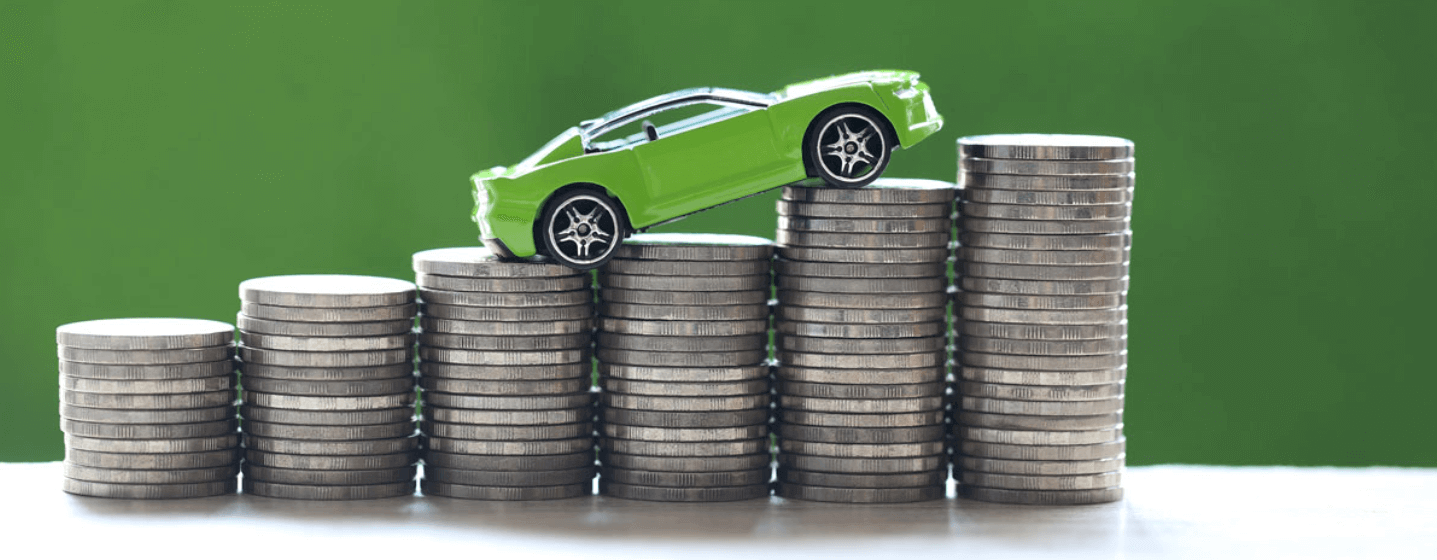

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# Data Story

### 🚗 AutoPrice AI: Unveiling the Secrets of Car Prices!

**Why are second-hand car prices so volatile? Why can the same model have price differences of thousands of dollars? We set out to answer these questions with AutoPrice AI, conducting an in-depth analysis.**

### 🧐 First Look at the Data

* **Kia Rio (2020) and Mercedes GLA (2020) have the same engine size and fuel type, yet their prices differ. Why?**

* **Chevrolet Malibu (2012) has only 5,356 km mileage, but its price is as high as $12,092. Is its hybrid nature affecting the price?**

* **Audi Q5 (2023) is electric but has a manual transmission. How does this impact its valuation?**

* **Volkswagen Golf (2003) is an old model but still on the market! With 286,618 km, its price is only $2,867.**

### 📊 What Are the Key Price Determinants?
**In this study, we analyze the impact of Mileage, Fuel Type, Transmission, Owner Count, and other factors on car prices. Are these truly the most important variables, or are there hidden factors at play?**

### 🚀 We Built Our Own Model!
**Through EDA (Exploratory Data Analysis), Feature Engineering, and Machine Learning Models, we are revolutionizing car price prediction.**

### 🔎 The Verdict?
**Data doesn't always behave as expected! Some cars are priced way above their "real" value, while others seem surprisingly underpriced. Which factor do you think is the most crucial?**

**👉 Check out our full analysis on Kaggle and share your insights! 🚗📈**

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# Roadmap

### 1. Import Required Libraries

### 2. Adjusting Row Column Settings

### 3. Loading The Dataset

### 4. Exploratory Data Analysis

### 5. Capturing / Detecting Numeric and Categorical Data

### 6. Analysis of Categorical Variables

### 7. Analysis of Numerical Variables

### 8. Analysis of Categorical Variables by Target

### 9. Analysis of Numeric Variables by Target

### 10. Correlation Analysis

### 11. The Relationship Between Variables

### 12. Outlier Analysis

### 13. Missing Value Analysis

### 14. Rare Analysis

### 15. Feature Extraction

### 16. Encoding

### 17. Standardization Process

### 18. Creating Model

### 19. Feature Importance

### 20. Final Model



<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 1. Import Required Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/2025-car/car_price_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import itertools
import plotly.graph_objects as go
import time

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV, ShuffleSplit, StratifiedKFold
from sklearn.model_selection import GridSearchCV, cross_validate, RandomizedSearchCV, validation_curve
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.simplefilter(action="ignore")

import warnings
warnings.simplefilter(action="ignore")

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 2. Adjusting Row Column Settings

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 3. Loading The Dataset

In [4]:
df = pd.read_csv("/kaggle/input/2025-car/car_price_dataset.csv")

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">



# 4. Exploratory Data Analysis

In [5]:
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.200,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.000,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.200,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.000,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.600,Hybrid,Semi-Automatic,286618,3,3,2867


In [6]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.select_dtypes(include=['number']).quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


check_df(df)

##################### Shape #####################
(10000, 10)
##################### Types #####################
Brand            object
Model            object
Year              int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Doors             int64
Owner_Count       int64
Price             int64
dtype: object
##################### Head #####################
        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020        4.200    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012        2.000    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020        4.200    Diesel       Automatic   231440   
3        Audi      Q5  2023        2.000  Electric          Manual   160971   
4  Volkswagen    Golf  2003        2.600    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  Price  
0      3            5   8501  
1      2            3  12092  
2      4         

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 5. Capturing / Detecting Numeric and Categorical Variables

In [7]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"] 

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]

    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat

    cat_cols = [col for col in cat_cols if col not in cat_but_car] 

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"] 

    num_cols = [col for col in num_cols if col not in num_but_cat] 
    
    print(f"Observations: {dataframe.shape[0]}") 
    print(f"Variables: {dataframe.shape[1]}") 
    print(f'cat_cols: {len(cat_cols)}') 
    print(f'num_cols: {len(num_cols)}') 
    print(f'cat_but_car: {len(cat_but_car)}') 
    print(f'num_but_cat: {len(num_but_cat)}') 


    return cat_cols, num_cols, cat_but_car, num_but_cat

In [8]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 10000
Variables: 10
cat_cols: 5
num_cols: 4
cat_but_car: 1
num_but_cat: 2


In [9]:
cat_cols

['Brand', 'Fuel_Type', 'Transmission', 'Doors', 'Owner_Count']

In [10]:
num_cols

['Year', 'Engine_Size', 'Mileage', 'Price']

In [11]:
cat_but_car

['Model']

In [12]:
df["Model"].nunique()

30

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 6. Analysis of Categorical Variables

In [13]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe, palette="Set2")
        plt.xticks(rotation=45)
        plt.show(block=True)

            Brand  Ratio
Brand                   
Ford         1048 10.480
Audi         1038 10.380
Volkswagen   1020 10.200
Honda        1009 10.090
Chevrolet    1003 10.030
BMW           999  9.990
Hyundai       995  9.950
Kia           976  9.760
Toyota        970  9.700
Mercedes      942  9.420
##########################################


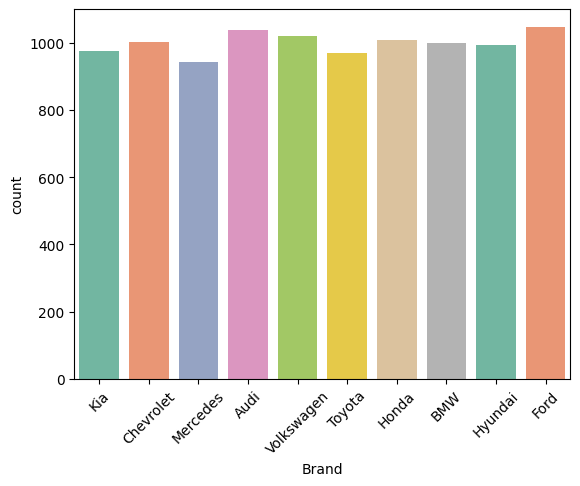

           Fuel_Type  Ratio
Fuel_Type                  
Electric        2625 26.250
Diesel          2512 25.120
Hybrid          2453 24.530
Petrol          2410 24.100
##########################################


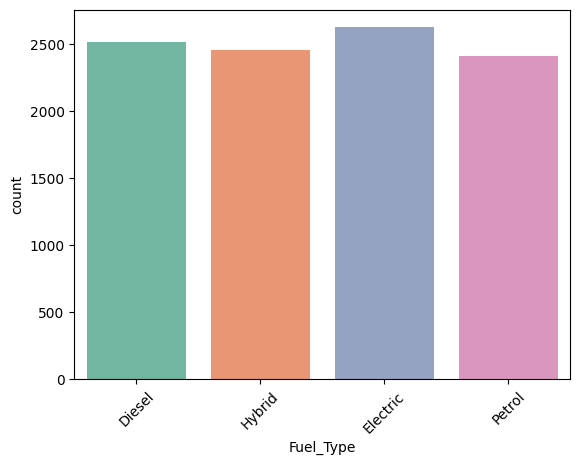

                Transmission  Ratio
Transmission                       
Manual                  3372 33.720
Automatic               3317 33.170
Semi-Automatic          3311 33.110
##########################################


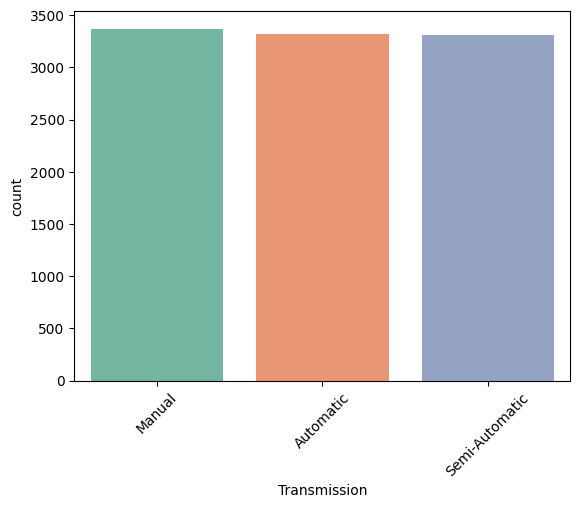

       Doors  Ratio
Doors              
3       2575 25.750
4       2514 25.140
5       2456 24.560
2       2455 24.550
##########################################


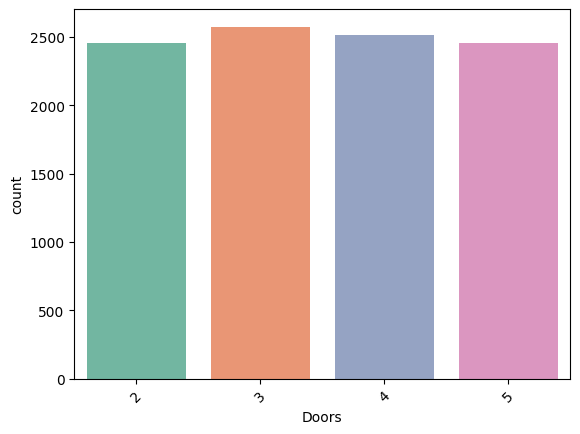

             Owner_Count  Ratio
Owner_Count                    
5                   2036 20.360
1                   2036 20.360
2                   2020 20.200
3                   1977 19.770
4                   1931 19.310
##########################################


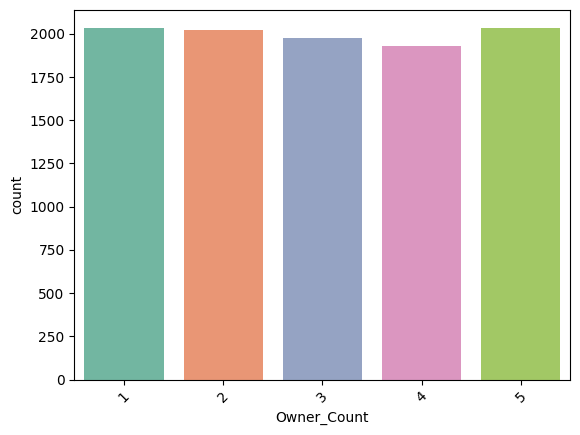

In [14]:
for col in cat_cols:
    cat_summary(df, col, plot=True)

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 7. Analysis of Numerical Variables

In [15]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

count   10000.000
mean     2011.544
std         6.898
min      2000.000
5%       2001.000
10%      2002.000
20%      2004.000
30%      2007.000
40%      2009.000
50%      2012.000
60%      2014.000
70%      2016.000
80%      2019.000
90%      2021.000
95%      2022.000
99%      2023.000
max      2023.000
Name: Year, dtype: float64


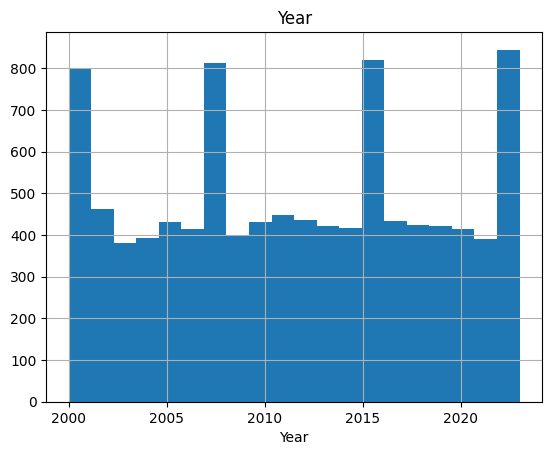

count   10000.000
mean        3.001
std         1.149
min         1.000
5%          1.200
10%         1.400
20%         1.800
30%         2.200
40%         2.600
50%         3.000
60%         3.400
70%         3.800
80%         4.200
90%         4.600
95%         4.800
99%         5.000
max         5.000
Name: Engine_Size, dtype: float64


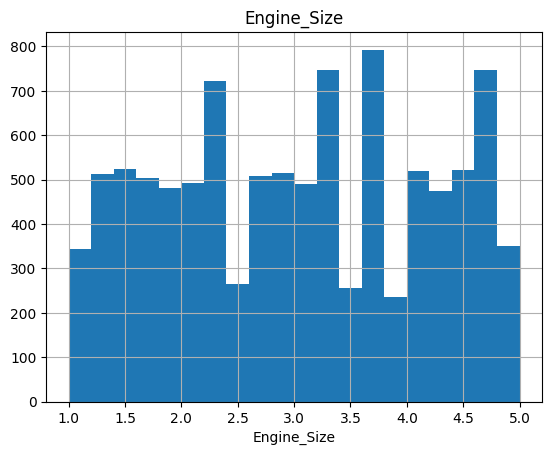

count    10000.000
mean    149239.112
std      86322.349
min         25.000
5%       14336.200
10%      29586.500
20%      59307.000
30%      89633.600
40%     119878.200
50%     149587.000
60%     179242.400
70%     208518.000
80%     238265.600
90%     269373.400
95%     284443.700
99%     296474.030
max     299947.000
Name: Mileage, dtype: float64


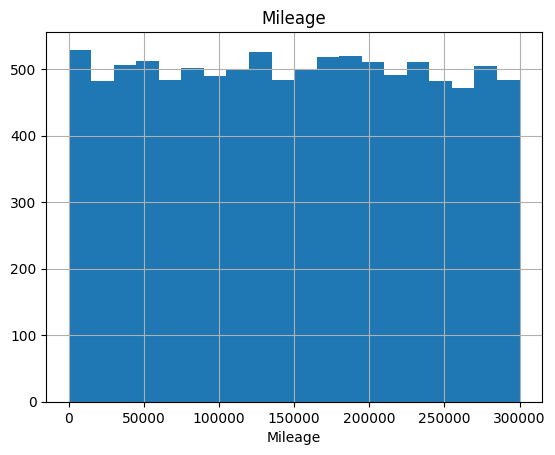

count   10000.000
mean     8852.964
std      3112.597
min      2000.000
5%       3655.000
10%      4672.400
20%      6067.400
30%      7127.700
40%      8038.000
50%      8858.500
60%      9701.400
70%     10577.000
80%     11602.600
90%     12945.300
95%     13981.050
99%     15745.080
max     18301.000
Name: Price, dtype: float64


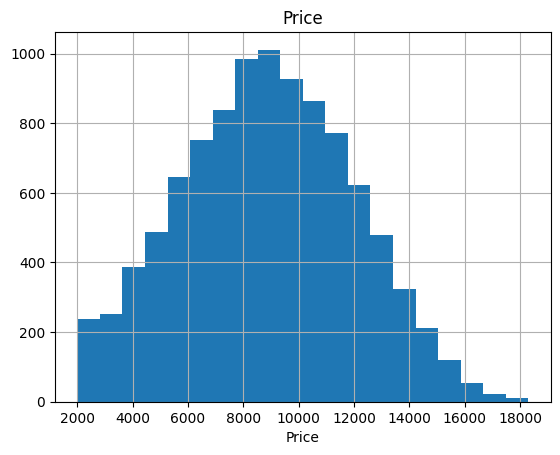

In [16]:
for col in num_cols:
    num_summary(df, col, plot=True)

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 8. Analysis of Categorical Variables by Target

In [17]:
def target_summary_with_cat(dataframe, target, categorical_col, plot=False):
    print(pd.DataFrame({'TARGET_MEAN': dataframe.groupby(categorical_col)[target].mean()}), end='\n\n\n')
    if plot:
        sns.barplot(x=categorical_col, y=target, data=dataframe)
        plt.show(block=True)

            TARGET_MEAN
Brand                  
Audi           8929.374
BMW            8704.068
Chevrolet      9015.684
Ford           8852.571
Honda          8665.597
Hyundai        8778.279
Kia            8880.086
Mercedes       8980.087
Toyota         8798.185
Volkswagen     8928.377




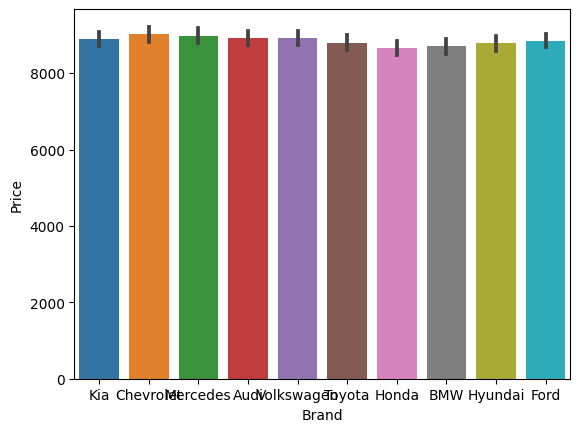

           TARGET_MEAN
Fuel_Type             
Diesel        8117.336
Electric     10032.220
Hybrid        9113.030
Petrol        8070.562




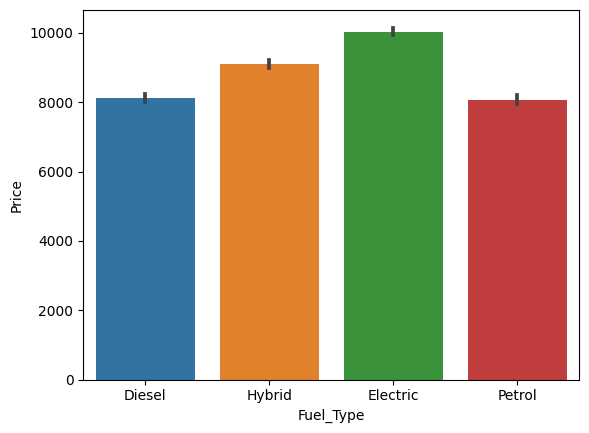

                TARGET_MEAN
Transmission               
Automatic          9938.253
Manual             8363.426
Semi-Automatic     8264.266




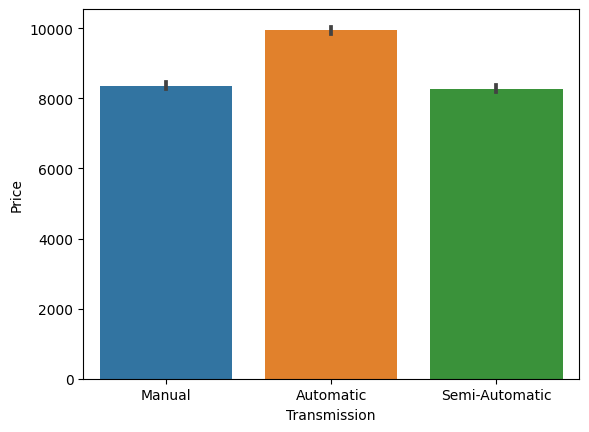

       TARGET_MEAN
Doors             
2         8928.931
3         8746.447
4         8841.588
5         8900.353




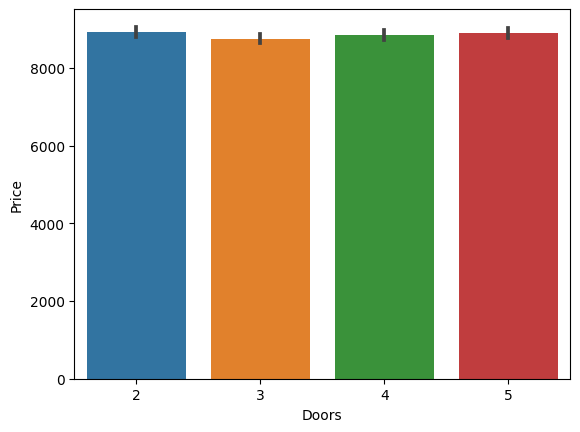

             TARGET_MEAN
Owner_Count             
1               8841.374
2               8847.258
3               8847.919
4               8869.173
5               8859.742




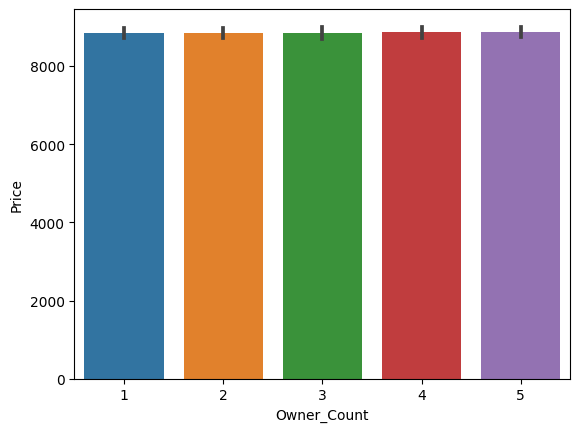

In [18]:
for col in cat_cols:
    target_summary_with_cat(df, "Price", col, plot=True)

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 9. Analysis of Numeric Variables by Target

In [19]:
def target_summary_with_num(dataframe, target, numerical_col, plot=False):
    print(pd.DataFrame({numerical_col+'_mean': dataframe.groupby(target)[numerical_col].mean()}), end='\n\n\n')
    if plot:
        sns.barplot(x=target, y=numerical_col, data=dataframe)
        plt.show(block=True)

In [20]:
for col in num_cols:
    target_summary_with_num(df, "Price", col, plot=False)

       Year_mean
Price           
2000    2001.742
2007    2008.000
2019    2007.000
2032    2002.000
2042    2001.000
...          ...
17899   2023.000
17906   2022.000
18017   2020.000
18255   2023.000
18301   2021.000

[6661 rows x 1 columns]


       Engine_Size_mean
Price                  
2000              1.745
2007              1.300
2019              1.400
2032              2.200
2042              1.400
...                 ...
17899             4.600
17906             4.000
18017             4.800
18255             5.000
18301             4.700

[6661 rows x 1 columns]


       Mileage_mean
Price              
2000     262524.215
2007     289632.000
2019     279031.000
2032     243388.000
2042     237884.000
...             ...
17899     10046.000
17906     14658.000
18017     19112.000
18255     12234.000
18301     14924.000

[6661 rows x 1 columns]


       Price_mean
Price            
2000     2000.000
2007     2007.000
2019     2019.000
2032     2032.000
2042     2042.000


<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 10. Correlation Analysis

In [21]:
corr = df[num_cols].corr()

In [22]:
corr

,Year,Engine_Size,Mileage,Price
Year,1.000,-0.001,-0.002,0.663
Engine_Size,-0.001,1.000,0.015,0.357
Mileage,-0.002,0.015,1.000,-0.551
Price,0.663,0.357,-0.551,1.000


In [23]:
def high_correlated_cols(dataframe, plot=False, corr_th=0.70):
    
    # Select numerical columns
    num_cols = dataframe.select_dtypes(include=['number']).columns
    
    # Calculate correlation matrix for numerical columns
    corr = dataframe[num_cols].corr()
    
    # Get the absolute value of the correlation matrix
    cor_matrix = corr.abs()
    
    # Select the upper triangle of the correlation matrix (excluding diagonal)
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
    
    # Get columns with high correlation above the threshold
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]
    
    # Plot the correlation heatmap if plot=True
    if plot:
        import seaborn as sns
        import matplotlib.pyplot as plt
        sns.set(rc={"figure.figsize": (8, 6)})
        corr_values = corr.round(2)
        sns.heatmap(corr, cmap="RdBu", annot=corr_values)
        plt.show(block=True)
    
    return drop_list

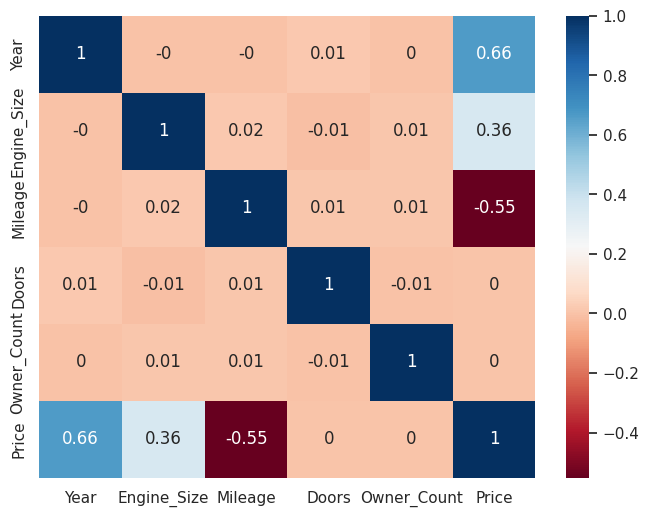

[]

In [24]:
high_correlated_cols(df, plot=True)

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 11. The Relationship Between Variables

In [25]:
# # Create combinations of binary categorical variables
# feature_combinations = list(itertools.combinations(['Year', 'Engine_Size', 'Mileage', 'Price'], 2))

# # Create a separate Bubble Chart for each binary categorical variable
# for i, (feature1, feature2) in enumerate(feature_combinations):
#     fig = px.scatter(df, x=feature1, y=feature2, color='Price', size='Year',
#                      title=f'{feature1} vs {feature2} Bubble Chart')

#     fig.show(block=True)

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 12. Outlier Analysis

In [26]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

In [27]:
def check_outlier(dataframe, col_name, plot=False):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)]
    if outliers.any(axis=None):
        if plot:
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=dataframe[col_name])
            plt.title(f'Outliers in {col_name}')
            plt.show()
        return True
    else:
        return False

In [28]:
def replace_with_thresholds(dataframe, variable, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, variable, q1=0.05, q3=0.95)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [29]:
for col in df.select_dtypes(include=['number']).columns:
    print(col, check_outlier(df, col, plot=False))
    if check_outlier(df, col, plot=False):
        replace_with_thresholds(df, col)

Year False
Engine_Size False
Mileage False
Doors False
Owner_Count False
Price False


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.000,2011.544,6.898,2000.000,2006.000,2012.000,2017.000,2023.000
Engine_Size,10000.000,3.001,1.149,1.000,2.000,3.000,4.000,5.000
Mileage,10000.000,149239.112,86322.349,25.000,74649.250,149587.000,223577.500,299947.000
Doors,10000.000,3.497,1.110,2.000,3.000,3.000,4.000,5.000
Owner_Count,10000.000,2.991,1.423,1.000,2.000,3.000,4.000,5.000
Price,10000.000,8852.964,3112.597,2000.000,6646.000,8858.500,11086.500,18301.000


<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 13. Missing Value Analysis

In [31]:
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 14. Rare Analysis

In [32]:
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ':', len(dataframe[col].value_counts()))
        print(pd.DataFrame({'COUNT': dataframe[col].value_counts(),
                            'RATIO': dataframe[col].value_counts() / len(dataframe),
                            'TARGET_MEAN': dataframe.groupby(col)[target].mean()}), end='\n\n\n')

In [33]:
cat_cols = ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Doors', 'Owner_Count']

In [34]:
rare_analyser(df, "Price", cat_cols)

Brand : 10
            COUNT  RATIO  TARGET_MEAN
Brand                                
Audi         1038  0.104     8929.374
BMW           999  0.100     8704.068
Chevrolet    1003  0.100     9015.684
Ford         1048  0.105     8852.571
Honda        1009  0.101     8665.597
Hyundai       995  0.100     8778.279
Kia           976  0.098     8880.086
Mercedes      942  0.094     8980.087
Toyota        970  0.097     8798.185
Volkswagen   1020  0.102     8928.377


Model : 30
          COUNT  RATIO  TARGET_MEAN
Model                              
3 Series    335  0.034     8854.752
5 Series    353  0.035     8669.218
A3          338  0.034     8912.317
A4          350  0.035     8919.963
Accord      365  0.036     8743.762
...         ...    ...          ...
Sonata      319  0.032     8740.831
Sportage    313  0.031     8867.636
Tiguan      352  0.035     9098.864
Tucson      329  0.033     8789.070
X5          311  0.031     8581.312

[30 rows x 3 columns]


Fuel_Type : 4
           CO

In [35]:
def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns if temp_df[col].dtypes == 'O'
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])
    return temp_df

In [36]:
df = rare_encoder(df, 0.01)

In [37]:
df["Model"].nunique()

30

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 15. Feature Extraction

In [38]:
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.200,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.000,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.200,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.000,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.600,Hybrid,Semi-Automatic,286618,3,3,2867


In [39]:
df["Mileage"].describe().T

count    10000.000
mean    149239.112
std      86322.349
min         25.000
25%      74649.250
50%     149587.000
75%     223577.500
max     299947.000
Name: Mileage, dtype: float64

In [40]:
df['Year_Segment'] = pd.cut(df['Year'], bins=[1999, 2005, 2010, 2015, 2020, 2025],
                         labels=[1, 2, 3, 4, 5], right=False).astype(int)

df['Engine_Segment'] = pd.cut(df['Engine_Size'], bins=[0, 1.5, 3, 5], 
                               labels=[1, 2, 3], right=True).astype(int)

df['Mileage_Segment'] = pd.cut(df['Mileage'], bins=[0, 50000, 100000, 150000, 200000, 250000, 300000], 
                               labels=[6, 5, 4, 3, 2, 1], right=True).astype(int)

In [41]:
df['Fuel_Segment'] = df['Fuel_Type'].replace({'Petrol': 1, 'Diesel': 2, 'Hybrid': 3, 'Electric': 4}).astype(int)
df['Transmission_segment'] = df['Transmission'].replace({'Semi-Automatic': 1, 'Manual': 2, 'Automatic': 3}).astype(int)

In [42]:
df["Model_Brand"] = df["Model"] + "_" + df["Brand"]
df["Year_Milage"] = df["Year_Segment"] * df['Mileage_Segment']
df["YME_Sum"] = df["Year_Segment"] + df['Mileage_Segment'] + df['Engine_Segment']
df["Year/Milage"] = df["Year_Segment"] / df['Mileage_Segment']
df["Fuel_Transmission"] = df['Fuel_Segment'] * df['Transmission_segment']

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 16. Encoding

In [43]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 10000
Variables: 20
cat_cols: 11
num_cols: 7
cat_but_car: 2
num_but_cat: 8


In [44]:
cat_cols = ['Brand',
            'Fuel_Type',
            'Transmission',
           'Model_Brand']

In [45]:
num_cols = ['Year', 
            'Engine_Size', 
            'Mileage', 
            'Price',
            'Year_Segment', 
            'Engine_Segment',
            'Mileage_Segment',
            'Fuel_Segment',
            'Transmission_segment',
            'Doors',
            'Owner_Count']

In [46]:
# Label Encoding

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

In [47]:
binary_cols = [col for col in df.columns if df[col].dtypes == "O" and df[col].nunique() == 2]

In [48]:
binary_cols

[]

In [49]:
# One-Hot Encoding

cat_cols = [col for col in cat_cols if col not in binary_cols]

In [50]:
cat_cols = ['Model_Brand']

In [51]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

In [52]:
df = one_hot_encoder(df, cat_cols, drop_first=True)

In [53]:
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price,Year_Segment,Engine_Segment,Mileage_Segment,Fuel_Segment,Transmission_segment,Year_Milage,YME_Sum,Year/Milage,Fuel_Transmission,Model_Brand_5 Series_BMW,Model_Brand_A3_Audi,Model_Brand_A4_Audi,Model_Brand_Accord_Honda,Model_Brand_C-Class_Mercedes,Model_Brand_CR-V_Honda,Model_Brand_Camry_Toyota,Model_Brand_Civic_Honda,Model_Brand_Corolla_Toyota,Model_Brand_E-Class_Mercedes,Model_Brand_Elantra_Hyundai,Model_Brand_Equinox_Chevrolet,Model_Brand_Explorer_Ford,Model_Brand_Fiesta_Ford,Model_Brand_Focus_Ford,Model_Brand_GLA_Mercedes,Model_Brand_Golf_Volkswagen,Model_Brand_Impala_Chevrolet,Model_Brand_Malibu_Chevrolet,Model_Brand_Optima_Kia,Model_Brand_Passat_Volkswagen,Model_Brand_Q5_Audi,Model_Brand_RAV4_Toyota,Model_Brand_Rio_Kia,Model_Brand_Sonata_Hyundai,Model_Brand_Sportage_Kia,Model_Brand_Tiguan_Volkswagen,Model_Brand_Tucson_Hyundai,Model_Brand_X5_BMW
0,Kia,Rio,2020,4.200,Diesel,Manual,289944,3,5,8501,5,3,1,2,2,5,9,5.000,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,Chevrolet,Malibu,2012,2.000,Hybrid,Automatic,5356,2,3,12092,3,2,6,3,3,18,11,0.500,9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,Mercedes,GLA,2020,4.200,Diesel,Automatic,231440,4,2,11171,5,3,2,2,3,10,10,2.500,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,Audi,Q5,2023,2.000,Electric,Manual,160971,2,1,11780,5,2,3,4,2,15,10,1.667,8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,Volkswagen,Golf,2003,2.600,Hybrid,Semi-Automatic,286618,3,3,2867,1,2,1,3,1,1,4,1.000,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 17. Standardization Process

In [54]:
scaler = RobustScaler()

In [55]:
df[num_cols] = scaler.fit_transform(df[num_cols])

In [56]:
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price,Year_Segment,Engine_Segment,Mileage_Segment,Fuel_Segment,Transmission_segment,Year_Milage,YME_Sum,Year/Milage,Fuel_Transmission,Model_Brand_5 Series_BMW,Model_Brand_A3_Audi,Model_Brand_A4_Audi,Model_Brand_Accord_Honda,Model_Brand_C-Class_Mercedes,Model_Brand_CR-V_Honda,Model_Brand_Camry_Toyota,Model_Brand_Civic_Honda,Model_Brand_Corolla_Toyota,Model_Brand_E-Class_Mercedes,Model_Brand_Elantra_Hyundai,Model_Brand_Equinox_Chevrolet,Model_Brand_Explorer_Ford,Model_Brand_Fiesta_Ford,Model_Brand_Focus_Ford,Model_Brand_GLA_Mercedes,Model_Brand_Golf_Volkswagen,Model_Brand_Impala_Chevrolet,Model_Brand_Malibu_Chevrolet,Model_Brand_Optima_Kia,Model_Brand_Passat_Volkswagen,Model_Brand_Q5_Audi,Model_Brand_RAV4_Toyota,Model_Brand_Rio_Kia,Model_Brand_Sonata_Hyundai,Model_Brand_Sportage_Kia,Model_Brand_Tiguan_Volkswagen,Model_Brand_Tucson_Hyundai,Model_Brand_X5_BMW
0,Kia,Rio,0.727,0.600,Diesel,Manual,0.942,0.000,1.000,-0.081,1.000,1.000,-1.000,-0.500,0.000,5,9,5.000,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,Chevrolet,Malibu,0.000,-0.500,Hybrid,Automatic,-0.968,-1.000,0.000,0.728,0.000,0.000,0.667,0.000,0.500,18,11,0.500,9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,Mercedes,GLA,0.727,0.600,Diesel,Automatic,0.550,1.000,-0.500,0.521,1.000,1.000,-0.667,-0.500,0.500,10,10,2.500,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,Audi,Q5,1.000,-0.500,Electric,Manual,0.076,-1.000,-1.000,0.658,1.000,0.000,-0.333,0.500,0.000,15,10,1.667,8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,Volkswagen,Golf,-0.818,-0.200,Hybrid,Semi-Automatic,0.920,0.000,0.000,-1.349,-1.000,0.000,-1.000,0.000,-0.500,1,4,1.000,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 18. Creating Model

In [57]:
X = df.drop(['Price', 'Brand', 'Model', 'Fuel_Type', 'Transmission'], axis=1)  # 'charges' dışındaki tüm sütunlar
y = df['Price']  # Hedef değişken

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


🔹 Model: LR
RMSE: 0.1024
R² Score: 0.9779
MAE: 0.0868
MSE: 0.0103
Execution Time: 0.15 seconds


🔹 Model: Ridge
RMSE: 0.1024
R² Score: 0.9778
MAE: 0.0869
MSE: 0.0103
Execution Time: 0.07 seconds


🔹 Model: Lasso
RMSE: 0.4457
R² Score: 0.5985
MAE: 0.3474
MSE: 0.1871
Execution Time: 0.1 seconds


🔹 Model: ElasticNet
RMSE: 0.4012
R² Score: 0.6713
MAE: 0.3147
MSE: 0.1531
Execution Time: 0.1 seconds


🔹 Model: KNN
RMSE: 0.1789
R² Score: 0.9376
MAE: 0.137
MSE: 0.0291
Execution Time: 1.02 seconds


🔹 Model: CART
RMSE: 0.1412
R² Score: 0.9666
MAE: 0.0975
MSE: 0.0156
Execution Time: 0.31 seconds


🔹 Model: RF
RMSE: 0.0964
R² Score: 0.9824
MAE: 0.0717
MSE: 0.0082
Execution Time: 18.01 seconds


🔹 Model: GBM
RMSE: 0.0719
R² Score: 0.9888
MAE: 0.0584
MSE: 0.0052
Execution Time: 6.21 seconds


🔹 Model: XGBoost
RMSE: 0.0439
R² Score: 0.9966
MAE: 0.0304
MSE: 0.0016
Execution Time: 0.93 seconds

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-cho

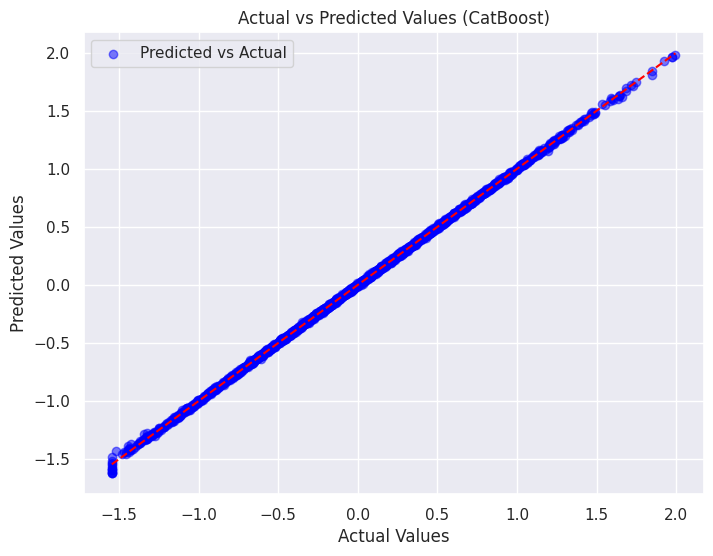

In [58]:
# Model listesini oluştur
models = [
    ('LR', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('ElasticNet', ElasticNet()),
    ('KNN', KNeighborsRegressor()),
    ('CART', DecisionTreeRegressor()),
    ('RF', RandomForestRegressor()),
    ('GBM', GradientBoostingRegressor()),
    ("XGBoost", XGBRegressor(objective='reg:squarederror')),
    ("LightGBM", LGBMRegressor()),
    ("CatBoost", CatBoostRegressor(verbose=False))
]

rmse_scores = []
r2_scores = []
mae_scores = []
mse_scores = []
execution_times = []
model_names = []

# Tüm modelleri değerlendir
for name, regressor in models:
    start_time = time.time()

    # Modeli eğit
    regressor.fit(X_train, y_train)

    # Tahmin yap
    y_pred = regressor.predict(X_test)

    # Performans metriklerini hesapla
    rmse = np.mean(np.sqrt(-cross_val_score(regressor, X_train, y_train, cv=5, scoring="neg_mean_squared_error")))
    r2 = metrics.r2_score(y_test, y_pred)
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    execution_time = time.time() - start_time

    # Sonuçları sakla
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mse_scores.append(mse)
    execution_times.append(execution_time)
    model_names.append(name)

    # Sonuçları yazdır
    print(f"\n🔹 Model: {name}")
    print(f"RMSE: {round(rmse, 4)}")
    print(f"R² Score: {round(r2, 4)}")
    print(f"MAE: {round(mae, 4)}")
    print(f"MSE: {round(mse, 4)}")
    print(f"Execution Time: {round(execution_time, 2)} seconds\n")

# En iyi modeli seç (en düşük RMSE'ye göre)
best_index = np.argmin(rmse_scores)
best_model_name = model_names[best_index]
best_model = models[best_index][1]

print(f"\n✅ En İyi Model: {best_model_name} (RMSE: {rmse_scores[best_index]:.4f})")

# Final model olarak en iyi modeli eğit
final_model = best_model
final_model.fit(X_train, y_train)

# Test seti üzerinde tahmin yap
y_pred = final_model.predict(X_test)

# Performans metriklerini hesapla
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Sonuçları yazdır
print("\n🚀 Final Model Performance")
print(f"Model: {best_model_name}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

# Gerçek ve tahmin edilen değerleri çizdirme
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted Values ({best_model_name})")
plt.legend()
plt.show()


<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 19. Feature Importance

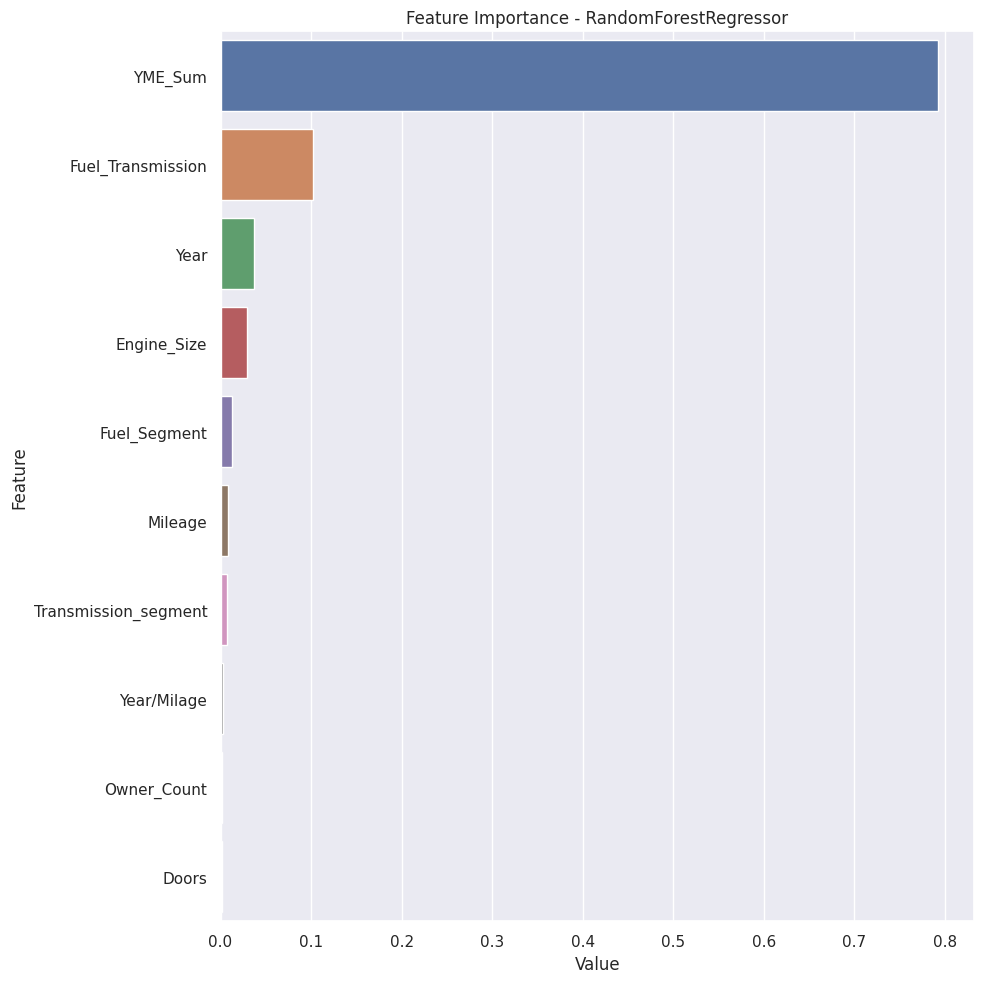

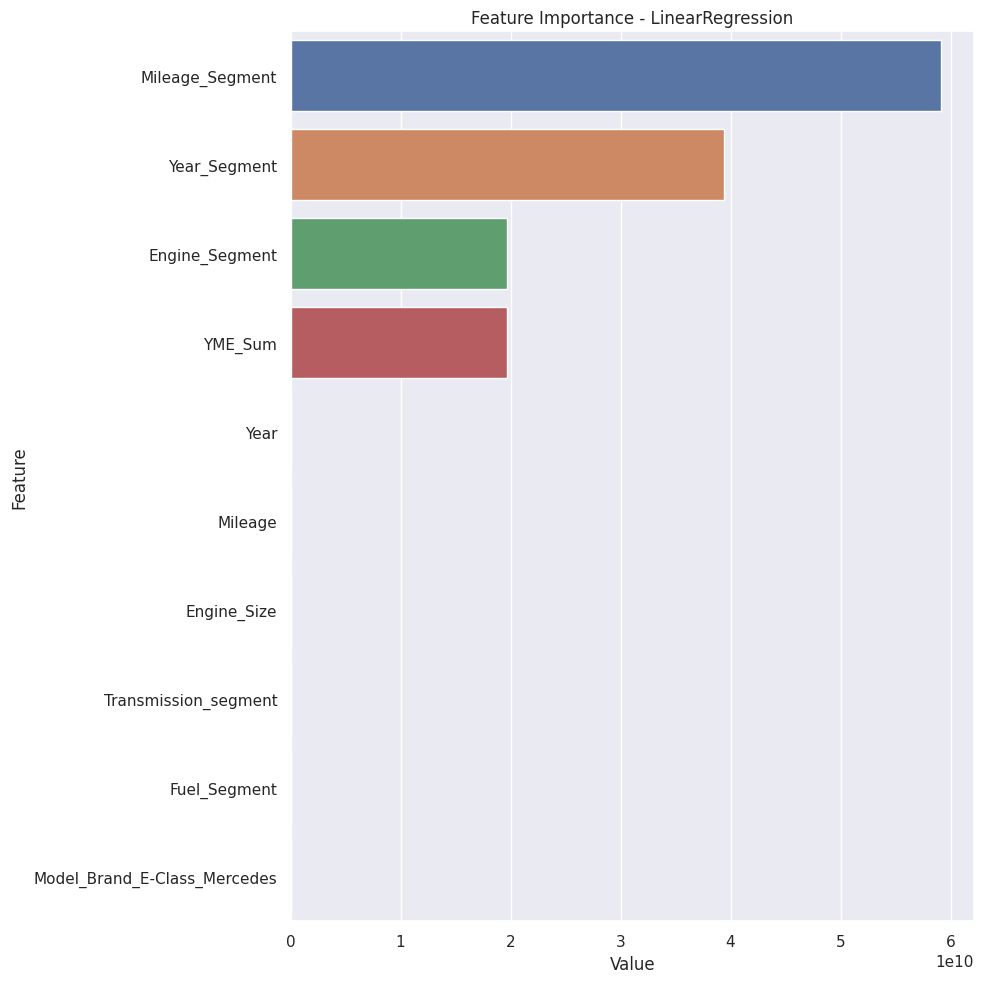

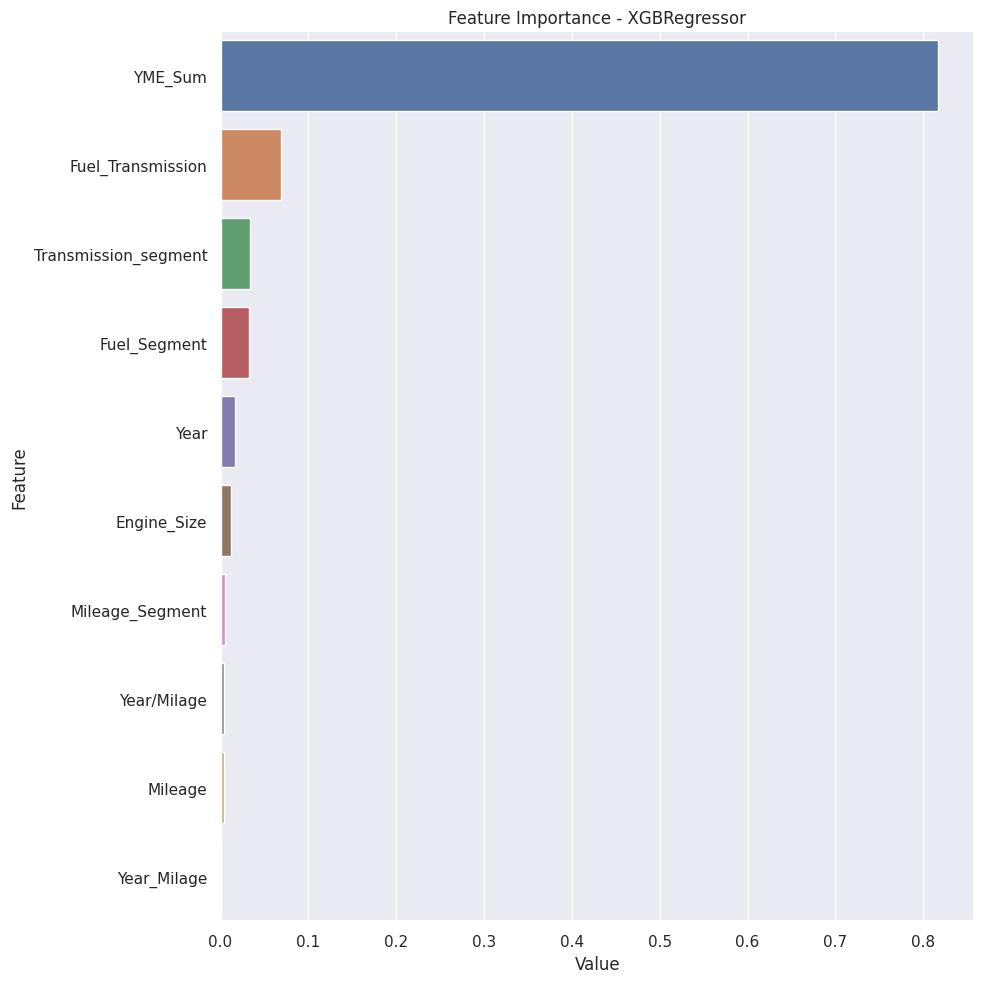

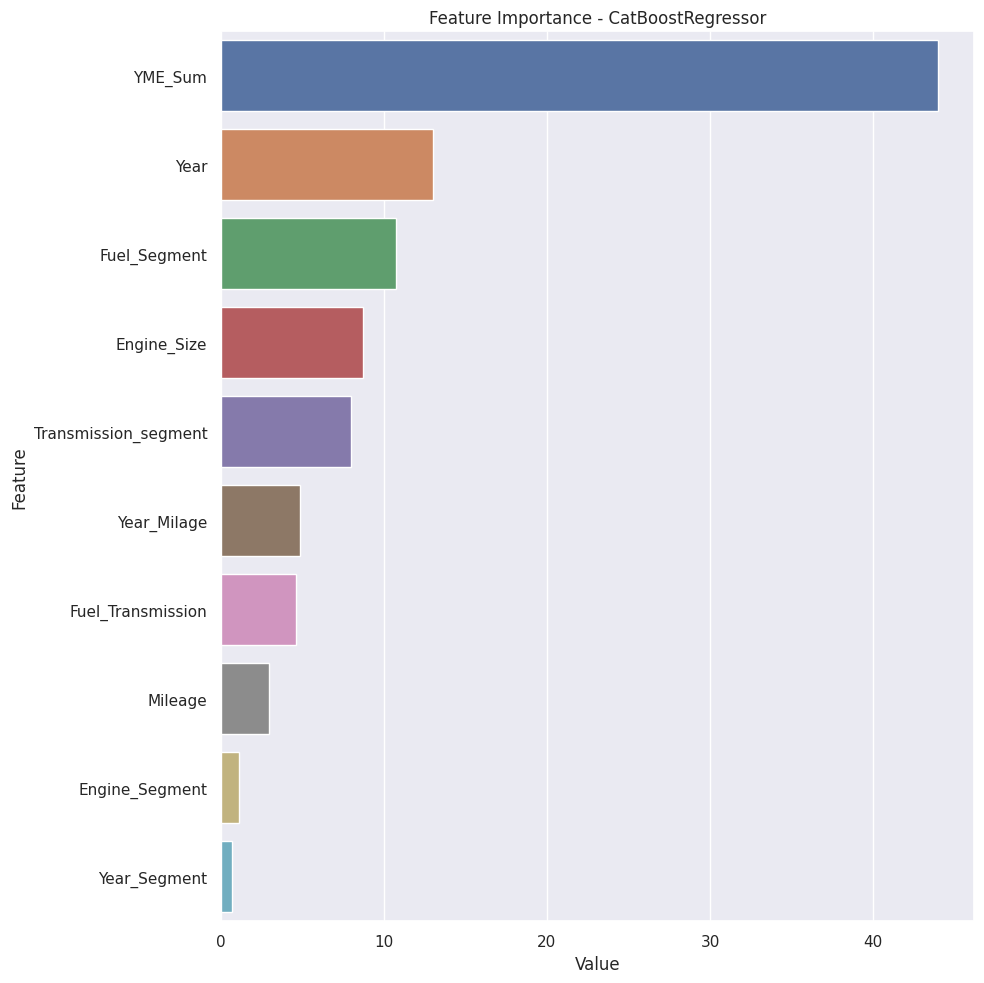

In [59]:
def plot_importance(model, features, num=None, save=False):
    # Plotlanacak özellik sayısını varsayılan olarak sütun sayısı olarak ayarla
    if num is None:
        num = len(features.columns)

    # Modelin feature importance özelliğini kontrol et
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # LogisticRegression gibi modeller için
        importances = model.coef_[0] if model.coef_.ndim == 2 else model.coef_
        importances = np.abs(importances)
    else:
        print(f"{model.__class__.__name__} modelinde özellik önem değerleri bulunamadı.")
        return

    feature_imp = pd.DataFrame({'Value': importances, 'Feature': features.columns})

    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature",
                data=feature_imp.sort_values(by="Value", ascending=False).iloc[:num])
    plt.title(f'Feature Importance - {model.__class__.__name__}')
    plt.tight_layout()
    if save:
        plt.savefig(f'importances_{model.__class__.__name__}.png')
    plt.show()

# Örnek kullanım:
models = [
    RandomForestRegressor(),
    LinearRegression(),  # LogisticRegression yerine LinearRegression
    XGBRegressor(),
    CatBoostRegressor(verbose=False, random_state=12345)
]

# X ve y eğitim verisi (örnek)
# X = ...  # Özellikler
# y = ...  # Etiketler

for model in models:
    model.fit(X, y)
    plot_importance(model, X, num=10, save=False)  # num: Görselleştireceğiniz özellik sayısı

<div style="border: 12px solid #28a745; background-color: #ffffff; color: #000000; padding: 10px; font-size: 24px; text-align: center;">


# 20. Final Model

LR - RMSE: 0.1016 | Execution Time: 0.01 sec
Ridge - RMSE: 0.1016 | Execution Time: 0.01 sec
Lasso - RMSE: 0.4325 | Execution Time: 0.01 sec
ElasticNet - RMSE: 0.3913 | Execution Time: 0.01 sec
KNN - RMSE: 0.1705 | Execution Time: 0.04 sec
CART - RMSE: 0.1240 | Execution Time: 0.06 sec
RF - RMSE: 0.0902 | Execution Time: 3.57 sec
GBM - RMSE: 0.0721 | Execution Time: 1.24 sec
XGBoost - RMSE: 0.0396 | Execution Time: 0.15 sec
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 470
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 43
[LightGBM] [Info] Start training from score -0.006701
LightGBM - RMSE: 0.0381 | Execution Time: 0.14 sec
CatBoost - RMSE: 0.0094 | Execution 

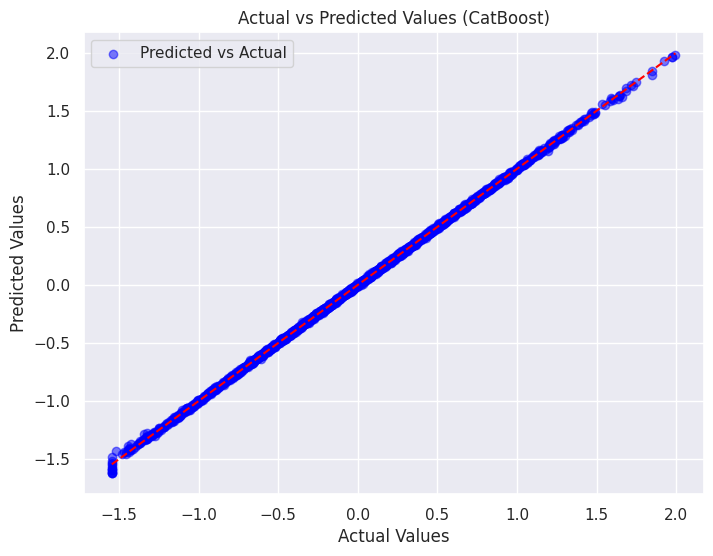

In [60]:
# Model listesini oluştur
models = [
    ('LR', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('ElasticNet', ElasticNet()),
    ('KNN', KNeighborsRegressor()),
    ('CART', DecisionTreeRegressor()),
    ('RF', RandomForestRegressor()),
    ('GBM', GradientBoostingRegressor()),
    ("XGBoost", XGBRegressor(objective='reg:squarederror')),
    ("LightGBM", LGBMRegressor()),
    ("CatBoost", CatBoostRegressor(verbose=False))
]

best_model = None
best_model_name = None
best_rmse = float("inf")

# En iyi modeli bul
for name, regressor in models:
    start_time = time.time()

    # Modeli eğit
    regressor.fit(X_train, y_train)

    # Tahmin yap
    y_pred = regressor.predict(X_test)

    # RMSE hesapla
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # En iyi modeli güncelle
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = regressor
        best_model_name = name

    execution_time = time.time() - start_time
    print(f"{name} - RMSE: {rmse:.4f} | Execution Time: {execution_time:.2f} sec")

# En iyi modeli kullanarak final modeli eğit
print(f"\n✅ En İyi Model: {best_model_name} (RMSE: {best_rmse:.4f})")
final_model = best_model
final_model.fit(X_train, y_train)

# Test seti üzerinde tahmin yap
y_pred = final_model.predict(X_test)

# Performans metriklerini hesapla
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Sonuçları yazdır
print("\n🚀 Final Model Performance")
print(f"Model: {best_model_name}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

# Gerçek ve tahmin edilen değerleri çizdirme
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted Values ({best_model_name})")
plt.legend()
plt.show()